# Übung 1

## Aufgabe Berry-Essen

Der Zentrale Grenzwertsatz nach Berry und Essen stellt einen allgemeinen Zusammenhang
zwischen der Verteilung einer standardisierten Summe von Zufallsvariablen und einer standardnormalverteilten
Zuvallsvariable auf. Untersuchen Sie, ob die Abschaetzung fuer verschiedene
Verteilungen der Summanden unterschiedlich scharf ist.

In [1]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

import importlib
import Uebung1_BerryEssen
importlib.reload(Uebung1_BerryEssen)

from Uebung1_BerryEssen import empirical_dist_zn, plot_zn_g, plot_diff_zn_g


# Verteilungs-Setup
rv_dict = {
    'N(0,1)': stats.norm,
    'Exp(1)': stats.expon,
    't, df=2.1': stats.t(2.1),
    't, df=3.1': stats.t(3.1),
    't, df=4.1': stats.t(4.1)
}

# Neue, manuell aufrufbare Funktion
def show_zn_g_deviations(n_per_sample=100, n_samples=1000,
                         distribution='N(0,1)',
                         plot_type='F(Zn) und F(g)'):
    if distribution not in rv_dict:
        raise ValueError(f"Verteilung '{distribution}' nicht gefunden.")
    
    dist = rv_dict[distribution]
    ecdf, rho = empirical_dist_zn(n_samples, n_per_sample, dist)
    
    fig, ax = plt.subplots()
    
    if plot_type == 'F(Zn) und F(g)':
        plot_zn_g(ecdf, rho, n_per_sample, ax=ax)
    elif plot_type == 'Difference':
        plot_diff_zn_g(ecdf, rho, n_per_sample, ax=ax)
    else:
        raise ValueError("Ungültiger plot_type. Benutze 'F(Zn) und F(g)' oder 'Difference'.")
    
    plt.show()


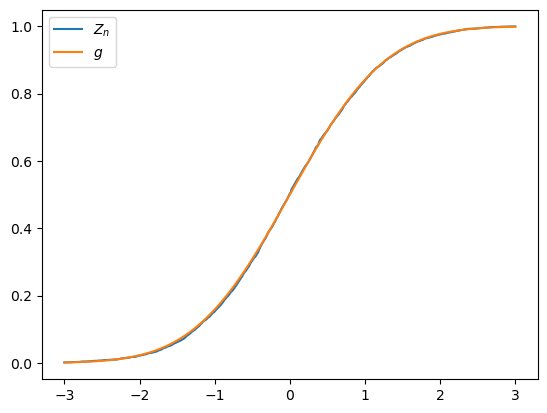

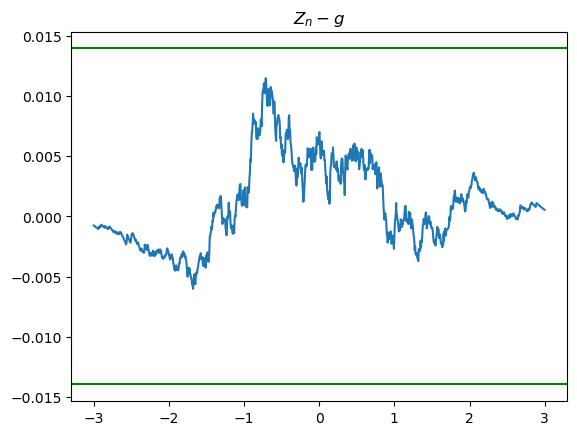

In [10]:
n_per_sample=30
show_zn_g_deviations(n_per_sample, n_samples=5000, distribution='Exp(1)', plot_type='F(Zn) und F(g)')
show_zn_g_deviations(n_per_sample, n_samples=5000, distribution='Exp(1)', plot_type='Difference')